## **Modelos Deep Learning em PyTorch**

**Tarefa 3 do Trabalho Prático — Aprendizagem Profunda**

Notebook que implementa e compara modelos PyTorch para classificação de texto (Human vs AI):

1. **DNN Baseline** — Feedforward com BatchNorm + Dropout (features tabulares TF-IDF)
2. **DNN Bottleneck** — Arquitetura estreita com regularização agressiva
3. **Embedding + DNN** — Embedding treinável sobre sequências de tokens + camadas densas
4. **BiLSTM** — LSTM bidirecional com embedding treinável
5. **BiLSTM + GloVe** — LSTM bidirecional com embeddings pré-treinados GloVe
6. **Comparação sistemática** de todas as variantes
7. **Avaliação final** — métricas, curvas, matrizes de confusão

### **1. Imports e Configuração**

In [39]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys, os, time, re
from collections import Counter
from sklearn.metrics import confusion_matrix, classification_report

# Adicionar o caminho para o diretório src
sys.path.append(os.path.abspath('../src'))
from utils import prepare_text_data, transform_new_texts, clean_text

# Configurar dispositivo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

Dispositivo: cuda


### **2. Carregamento e Preparação dos Dados**

Preparamos dois pipelines paralelos:
- **Pipeline tabular** (TF-IDF + estilísticas) → para as DNNs
- **Pipeline sequencial** (tokenização + padding) → para Embedding, BiLSTM e BiLSTM+GloVe

In [40]:
print('A carregar os datasets...')

# Dataset de treino e validação
df_train_val = pd.read_csv('../data/dataset.csv', sep=';')
df_train_val.columns = df_train_val.columns.str.lower()
textos_train_val = df_train_val['text'].tolist()
labels_train_val = df_train_val['label'].tolist()

# Dataset de teste
df_test = pd.read_csv('../data/raw/dataset-exemplos.csv', sep=';')
df_test.columns = df_test.columns.str.lower()
textos_test = df_test['text'].tolist()
labels_test = df_test['label'].tolist()

print(f'  Dataset treino e validação: {len(textos_train_val)} textos')
print(f'  Dataset teste: {len(textos_test)} textos')

# ── Pipeline Tabular (TF-IDF) ──
print('\nA processar features tabulares (TF-IDF word + char + estilísticas)...')
X_train, Y_train_oh, X_val, Y_val_oh, transformers, encoder = prepare_text_data(
    textos_train_val,
    labels_train_val,
    max_features=1500,
    char_features=1500,
    val_size=0.25,
    use_stratify=True,
    ngram_range=(1, 2)
)

print('A processar features de teste...')
X_test = transform_new_texts(textos_test, transformers)
Y_test_oh = encoder.transform(np.array(labels_test))

# Converter one-hot para índices
y_train = np.argmax(Y_train_oh, axis=1)
y_val = np.argmax(Y_val_oh, axis=1)
y_test = np.argmax(Y_test_oh, axis=1)

class_names = encoder.classes
print(f'\n✅ Classes: {list(class_names)}')
print(f'  Treino: {X_train.shape} | Validação: {X_val.shape} | Teste: {X_test.shape}')

A carregar os datasets...
  Dataset treino e validação: 5000 textos
  Dataset teste: 125 textos

A processar features tabulares (TF-IDF word + char + estilísticas)...
A processar features de teste...

✅ Classes: [np.str_('Anthropic'), np.str_('Google'), np.str_('Human'), np.str_('Meta'), np.str_('OpenAI')]
  Treino: (3750, 3013) | Validação: (1250, 3013) | Teste: (125, 3013)


#### **2.1 Pipeline Sequencial (para Embedding e BiLSTM)**

Tokenização simples, vocabulário de 10k tokens, padding fixo a 150.

In [41]:
# ── Pipeline Sequencial ──
from utils import train_test_split

texts_train_seq, texts_val_seq, labels_train_seq, labels_val_seq = train_test_split(
    textos_train_val, labels_train_val,
    test_size=0.25, random_state=42, stratify=labels_train_val
)

def simple_tokenize(text):
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    return [t for t in text.split() if len(t) > 1]

VOCAB_SIZE = 10000
MAX_SEQ_LEN = 150
PAD_IDX = 0

word_counts = Counter()
for text in texts_train_seq:
    word_counts.update(simple_tokenize(text))

most_common = word_counts.most_common(VOCAB_SIZE - 2)
word2idx = {word: idx + 2 for idx, (word, _) in enumerate(most_common)}
word2idx['<PAD>'] = PAD_IDX
word2idx['<UNK>'] = 1
actual_vocab_size = len(word2idx)

def texts_to_sequences(texts, word2idx, max_len):
    sequences = []
    for text in texts:
        tokens = simple_tokenize(text)
        seq = [word2idx.get(t, 1) for t in tokens[:max_len]]
        seq = seq + [PAD_IDX] * (max_len - len(seq))
        sequences.append(seq)
    return np.array(sequences)

seq_train = texts_to_sequences(texts_train_seq, word2idx, MAX_SEQ_LEN)
seq_val = texts_to_sequences(texts_val_seq, word2idx, MAX_SEQ_LEN)
seq_test = texts_to_sequences(textos_test, word2idx, MAX_SEQ_LEN)

y_train_seq = np.array([list(class_names).index(l) for l in labels_train_seq])
y_val_seq = np.array([list(class_names).index(l) for l in labels_val_seq])
y_test_seq = np.array([list(class_names).index(l) for l in labels_test])

print(f'Vocabulário: {actual_vocab_size} tokens')
print(f'Sequências — Treino: {seq_train.shape} | Val: {seq_val.shape} | Teste: {seq_test.shape}')

Vocabulário: 10000 tokens
Sequências — Treino: (3750, 150) | Val: (1250, 150) | Teste: (125, 150)


#### **2.2 Carregamento de Embeddings Pré-treinados (GloVe)**

Usamos GloVe 6B 100d — embeddings treinados em 6 mil milhões de tokens da Wikipedia + Gigaword.
Palavras do nosso vocabulário que existam no GloVe recebem a representação pré-treinada;
as restantes são inicializadas aleatoriamente.

In [42]:
import zipfile, urllib.request

GLOVE_DIM = 100
GLOVE_DIR = '../data/glove'
GLOVE_PATH = os.path.join(GLOVE_DIR, f'glove.6B.{GLOVE_DIM}d.txt')

# Download se necessário
if not os.path.exists(GLOVE_PATH):
    os.makedirs(GLOVE_DIR, exist_ok=True)
    zip_path = os.path.join(GLOVE_DIR, 'glove.6B.zip')
    if not os.path.exists(zip_path):
        print('A descarregar GloVe 6B (822MB)... pode demorar alguns minutos.')
        urllib.request.urlretrieve('https://nlp.stanford.edu/data/glove.6B.zip', zip_path)
        print('Download concluído.')
    print('A extrair...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extract(f'glove.6B.{GLOVE_DIM}d.txt', GLOVE_DIR)
    print('Extração concluída.')
else:
    print(f'GloVe já disponível em {GLOVE_PATH}')

# Carregar vetores GloVe
print(f'A carregar GloVe {GLOVE_DIM}d...')
glove_vectors = {}
with open(GLOVE_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        parts = line.strip().split()
        word = parts[0]
        if word in word2idx:  # só carregar palavras do nosso vocabulário
            vec = np.array(parts[1:], dtype=np.float32)
            glove_vectors[word] = vec

# Construir matriz de embeddings
embedding_matrix = np.random.normal(scale=0.6, size=(actual_vocab_size, GLOVE_DIM))
embedding_matrix[PAD_IDX] = np.zeros(GLOVE_DIM)  # padding = zeros

found = 0
for word, idx in word2idx.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1

coverage = found / (actual_vocab_size - 2) * 100  # excluir PAD e UNK
print(f'\n✅ GloVe carregado: {found}/{actual_vocab_size-2} palavras encontradas ({coverage:.1f}% cobertura)')
print(f'   Matriz de embeddings: {embedding_matrix.shape}')

GloVe já disponível em ../data/glove\glove.6B.100d.txt
A carregar GloVe 100d...

✅ GloVe carregado: 9722/9998 palavras encontradas (97.2% cobertura)
   Matriz de embeddings: (10000, 100)


#### **2.3 Conversão para Tensores PyTorch**

In [43]:
# ── Tensores tabulares ──
X_train_t = torch.FloatTensor(X_train).to(device)
y_train_t = torch.LongTensor(y_train).to(device)
X_val_t = torch.FloatTensor(X_val).to(device)
y_val_t = torch.LongTensor(y_val).to(device)
X_test_t = torch.FloatTensor(X_test).to(device)
y_test_t = torch.LongTensor(y_test).to(device)

# ── Tensores sequenciais ──
seq_train_t = torch.LongTensor(seq_train).to(device)
y_train_seq_t = torch.LongTensor(y_train_seq).to(device)
seq_val_t = torch.LongTensor(seq_val).to(device)
y_val_seq_t = torch.LongTensor(y_val_seq).to(device)
seq_test_t = torch.LongTensor(seq_test).to(device)
y_test_seq_t = torch.LongTensor(y_test_seq).to(device)

# DataLoaders
BATCH_SIZE = 128

train_loader_tab = DataLoader(
    TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader_tab = DataLoader(
    TensorDataset(X_val_t, y_val_t), batch_size=256, shuffle=False)

train_loader_seq = DataLoader(
    TensorDataset(seq_train_t, y_train_seq_t), batch_size=BATCH_SIZE, shuffle=True)
val_loader_seq = DataLoader(
    TensorDataset(seq_val_t, y_val_seq_t), batch_size=256, shuffle=False)

input_size = X_train_t.shape[1]
num_classes = len(class_names)
print(f'Input tabular: {input_size} | Vocab: {actual_vocab_size} | Classes: {num_classes} | Batch: {BATCH_SIZE}')

Input tabular: 3013 | Vocab: 10000 | Classes: 5 | Batch: 128


### **3. Função de Treino Genérica**

Uma única função que treina qualquer modelo PyTorch, com suporte a:
- Early stopping com restauração dos melhores pesos
- Learning rate scheduling (ReduceLROnPlateau)
- Registo de métricas (loss e accuracy para treino e validação)
- Suporte a dados tabulares e sequenciais

In [44]:
def treinar_modelo(model, nome, train_loader, val_loader,
                   X_full_train, y_full_train, X_full_val, y_full_val,
                   X_full_test, y_full_test,
                   epochs=150, lr=0.001, weight_decay=1e-4,
                   patience=10, use_scheduler=True):
    """
    Treina um modelo PyTorch e retorna métricas completas.
    Aceita tanto dados tabulares como sequenciais.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    scheduler = None
    if use_scheduler:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )

    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
    best_val_loss = float('inf')
    patience_counter = 0
    best_state = None

    print(f'{nome}')

    t0 = time.time()

    for epoch in range(epochs):
        model.train()
        epoch_loss = 0
        correct_train = 0
        total_train = 0

        for batch_X, batch_y in train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total_train += batch_y.size(0)
            correct_train += (predicted == batch_y).sum().item()

        avg_train_loss = epoch_loss / len(train_loader)
        train_acc = correct_train / total_train

        model.eval()
        val_loss_sum = 0
        correct_val = 0
        total_val = 0

        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                val_loss_sum += loss.item()
                _, predicted = torch.max(outputs, 1)
                total_val += batch_y.size(0)
                correct_val += (predicted == batch_y).sum().item()

        avg_val_loss = val_loss_sum / len(val_loader)
        val_acc = correct_val / total_val

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(avg_val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        if scheduler:
            scheduler.step(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            patience_counter = 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1

        if (epoch + 1) % 10 == 0:
            current_lr = optimizer.param_groups[0]['lr']
            print(f'  Época {epoch+1:3d}/{epochs} | Train Loss: {avg_train_loss:.4f} | '
                  f'Val Loss: {avg_val_loss:.4f} | Val Acc: {val_acc:.2%} | LR: {current_lr:.6f}')

        if patience_counter >= patience:
            print(f'  Early Stopping na época {epoch+1}!')
            break

    tempo = time.time() - t0

    if best_state:
        model.load_state_dict(best_state)

    model.eval()
    with torch.no_grad():
        train_out = model(X_full_train)
        train_acc_final = (torch.argmax(train_out, 1) == y_full_train).float().mean().item()
        train_loss_final = criterion(train_out, y_full_train).item()
        val_out = model(X_full_val)
        val_acc_final = (torch.argmax(val_out, 1) == y_full_val).float().mean().item()
        val_loss_final = criterion(val_out, y_full_val).item()
        test_out = model(X_full_test)
        test_acc_final = (torch.argmax(test_out, 1) == y_full_test).float().mean().item()
        test_loss_final = criterion(test_out, y_full_test).item()

    print(f'\n  Treino    — Acc: {train_acc_final:.2%}')
    print(f'  Validação — Acc: {val_acc_final:.2%}')
    print(f'  Teste     — Acc: {test_acc_final:.2%}')
    print(f'  Tempo: {tempo:.1f}s')

    return model, {
        'nome': nome,
        'train_acc': train_acc_final, 'val_acc': val_acc_final, 'test_acc': test_acc_final,
        'train_loss': train_loss_final, 'val_loss': val_loss_final, 'test_loss': test_loss_final,
        'tempo': tempo, 'history': history
    }

### **4. Definição dos Modelos**

Cinco arquiteturas que cobrem os requisitos do enunciado:

| Modelo | Tipo | Input | Descrição |
|--------|------|-------|-----------|
| **A — DNN BatchNorm** | Feedforward | TF-IDF tabular | BatchNorm + Dropout |
| **B — DNN Bottleneck** | Feedforward | TF-IDF tabular | Arquitetura estreita, regularização forte |
| **C — Embedding + DNN** | Embedding → Dense | Sequências | Embedding treinável + GlobalAvgPool |
| **D — BiLSTM** | Embedding → LSTM | Sequências | LSTM bidirecional, embedding treinável |
| **E — BiLSTM + GloVe** | Embedding → LSTM | Sequências | LSTM bidirecional, embedding pré-treinado GloVe 100d |

In [45]:
# ── Modelo A: DNN com BatchNorm ──
class DNNBatchNorm(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(256, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ── Modelo B: DNN Bottleneck ──
class DNNBottleneck(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(32, num_classes)
        )

    def forward(self, x):
        return self.net(x)


# ── Modelo C: Embedding + DNN ──
class EmbeddingDNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.net = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        embedded = self.embedding(x)
        mask = (x != 0).unsqueeze(-1).float()
        summed = (embedded * mask).sum(dim=1)
        lengths = mask.sum(dim=1).clamp(min=1)
        pooled = summed / lengths
        return self.net(pooled)


# ── Modelo D: BiLSTM (embedding treinável) ──
class BiLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=pad_idx)
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, (hidden, _) = self.lstm(embedded)
        hidden_fwd = hidden[-2]
        hidden_bwd = hidden[-1]
        combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)


# ── Modelo E: BiLSTM + GloVe (embedding pré-treinado) ──
class BiLSTMGloVe(nn.Module):
    def __init__(self, embedding_matrix, hidden_dim, num_classes,
                 num_layers=2, dropout=0.3, freeze_embed=False):
        super().__init__()
        vocab_size, embed_dim = embedding_matrix.shape
        self.embedding = nn.Embedding.from_pretrained(
            torch.FloatTensor(embedding_matrix),
            freeze=freeze_embed,
            padding_idx=0
        )
        self.lstm = nn.LSTM(
            embed_dim, hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        lstm_out, (hidden, _) = self.lstm(embedded)
        hidden_fwd = hidden[-2]
        hidden_bwd = hidden[-1]
        combined = torch.cat([hidden_fwd, hidden_bwd], dim=1)
        combined = self.dropout(combined)
        return self.fc(combined)


# Resumo dos modelos
EMBED_DIM = 64
HIDDEN_DIM = 64
HIDDEN_DIM_GLOVE = 128  # Mais capacidade para aproveitar os embeddings GloVe
print('Modelos definidos:')
models_info = [
    ('A - DNN BatchNorm', DNNBatchNorm(input_size, num_classes)),
    ('B - DNN Bottleneck', DNNBottleneck(input_size, num_classes)),
    ('C - Embedding+DNN', EmbeddingDNN(actual_vocab_size, EMBED_DIM, num_classes)),
    ('D - BiLSTM', BiLSTM(actual_vocab_size, EMBED_DIM, HIDDEN_DIM, num_classes)),
    ('E - BiLSTM+GloVe', BiLSTMGloVe(embedding_matrix, HIDDEN_DIM_GLOVE, num_classes, freeze_embed=True)),
]
for name, m in models_info:
    n_params = sum(p.numel() for p in m.parameters())
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  {name}: {n_params:,} params ({trainable:,} treináveis)')

Modelos definidos:
  A - DNN BatchNorm: 788,997 params (788,997 treináveis)
  B - DNN Bottleneck: 390,405 params (390,405 treináveis)
  C - Embedding+DNN: 657,285 params (657,285 treináveis)
  D - BiLSTM: 806,533 params (806,533 treináveis)
  E - BiLSTM+GloVe: 1,647,557 params (647,557 treináveis)


### **5. Treino dos Modelos**

In [46]:
torch.manual_seed(42)
np.random.seed(42)

resultados = {}
modelos = {}

# ── Modelo A — DNN BatchNorm (tabular) ──
model_a, res_a = treinar_modelo(
    DNNBatchNorm(input_size, num_classes),
    'DNN A — BatchNorm',
    train_loader_tab, val_loader_tab,
    X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t,
    lr=0.001, weight_decay=1e-3, patience=10
)
resultados['A'] = res_a
modelos['A'] = model_a

# ── Modelo B — DNN Bottleneck (tabular) ──
torch.manual_seed(42)
model_b, res_b = treinar_modelo(
    DNNBottleneck(input_size, num_classes),
    'DNN B — Bottleneck',
    train_loader_tab, val_loader_tab,
    X_train_t, y_train_t, X_val_t, y_val_t, X_test_t, y_test_t,
    lr=0.001, weight_decay=1e-3, patience=10
)
resultados['B'] = res_b
modelos['B'] = model_b

# ── Modelo C — Embedding + DNN (sequencial) ──
torch.manual_seed(42)
model_c, res_c = treinar_modelo(
    EmbeddingDNN(actual_vocab_size, EMBED_DIM, num_classes),
    'Embedding + DNN',
    train_loader_seq, val_loader_seq,
    seq_train_t, y_train_seq_t, seq_val_t, y_val_seq_t, seq_test_t, y_test_seq_t,
    lr=0.001, weight_decay=1e-4, patience=10
)
resultados['C'] = res_c
modelos['C'] = model_c

# ── Modelo D — BiLSTM (sequencial, embedding treinável) ──
torch.manual_seed(42)
model_d, res_d = treinar_modelo(
    BiLSTM(actual_vocab_size, EMBED_DIM, HIDDEN_DIM, num_classes),
    'BiLSTM',
    train_loader_seq, val_loader_seq,
    seq_train_t, y_train_seq_t, seq_val_t, y_val_seq_t, seq_test_t, y_test_seq_t,
    lr=0.001, weight_decay=1e-4, patience=10
)
resultados['D'] = res_d
modelos['D'] = model_d

# ── Modelo E — BiLSTM + GloVe (fine-tuning) ──
torch.manual_seed(42)
model_e, res_e = treinar_modelo(
    BiLSTMGloVe(embedding_matrix, HIDDEN_DIM_GLOVE, num_classes, freeze_embed=True),
    'BiLSTM + GloVe',
    train_loader_seq, val_loader_seq,
    seq_train_t, y_train_seq_t, seq_val_t, y_val_seq_t, seq_test_t, y_test_seq_t,
    lr=0.001, weight_decay=1e-4, patience=15
)
resultados['E'] = res_e
modelos['E'] = model_e

DNN A — BatchNorm
  Época  10/150 | Train Loss: 0.1004 | Val Loss: 0.5393 | Val Acc: 81.44% | LR: 0.001000
  Early Stopping na época 15!

  Treino    — Acc: 99.12%
  Validação — Acc: 82.72%
  Teste     — Acc: 62.40%
  Tempo: 5.4s
DNN B — Bottleneck
  Época  10/150 | Train Loss: 0.2741 | Val Loss: 0.5329 | Val Acc: 80.72% | LR: 0.001000
  Early Stopping na época 19!

  Treino    — Acc: 99.52%
  Validação — Acc: 82.08%
  Teste     — Acc: 64.00%
  Tempo: 6.0s
Embedding + DNN
  Época  10/150 | Train Loss: 0.9898 | Val Loss: 1.0756 | Val Acc: 58.24% | LR: 0.001000
  Época  20/150 | Train Loss: 0.5240 | Val Loss: 0.8948 | Val Acc: 64.96% | LR: 0.001000
  Época  30/150 | Train Loss: 0.2641 | Val Loss: 0.9284 | Val Acc: 67.92% | LR: 0.000500
  Early Stopping na época 30!

  Treino    — Acc: 89.33%
  Validação — Acc: 64.96%
  Teste     — Acc: 60.00%
  Tempo: 12.2s
BiLSTM
  Época  10/150 | Train Loss: 1.3413 | Val Loss: 1.3201 | Val Acc: 43.76% | LR: 0.001000
  Época  20/150 | Train Loss: 1.1164

### **6. Curvas de Aprendizagem**

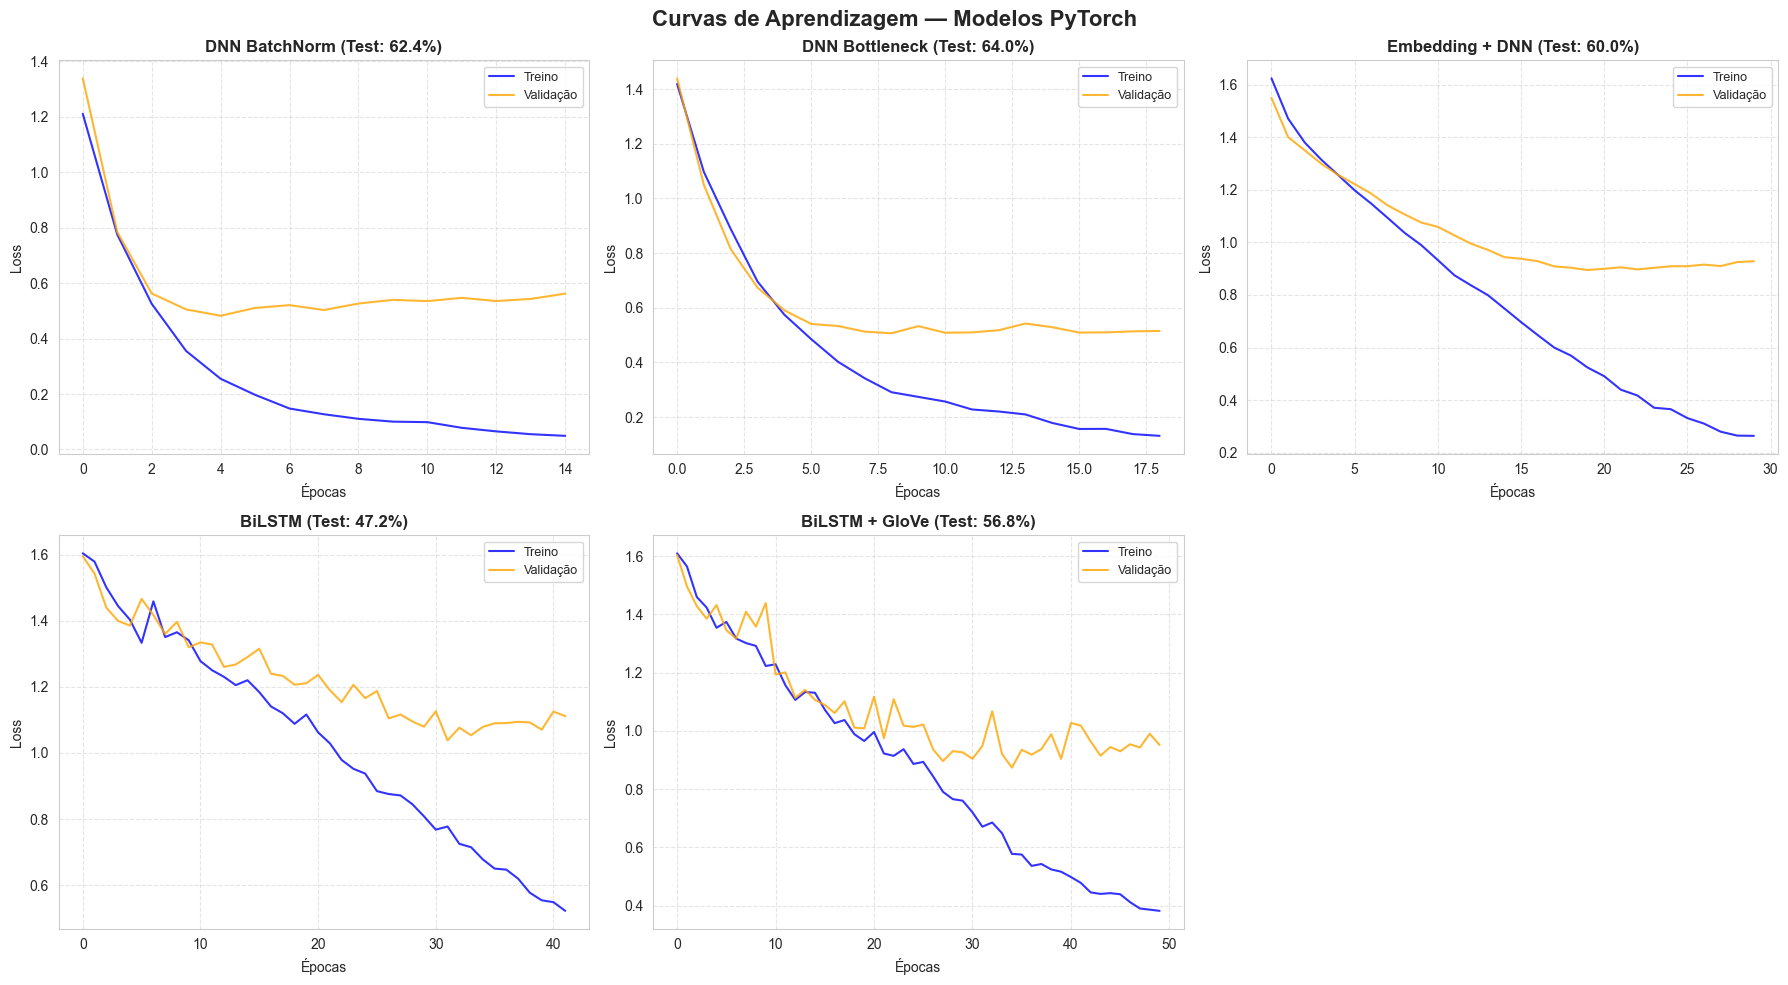

In [47]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

modelos_plot = [
    ('DNN BatchNorm', res_a), ('DNN Bottleneck', res_b),
    ('Embedding + DNN', res_c), ('BiLSTM', res_d),
    ('BiLSTM + GloVe', res_e),
]

for idx, (nome, res) in enumerate(modelos_plot):
    ax = axes[idx // 3][idx % 3]
    ax.plot(res['history']['train_loss'], label='Treino', color='blue', alpha=0.8)
    ax.plot(res['history']['val_loss'], label='Validação', color='orange', alpha=0.8)
    ax.set_title(f"{nome} (Test: {res['test_acc']:.1%})", fontweight='bold')
    ax.set_xlabel('Épocas')
    ax.set_ylabel('Loss')
    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.5)

axes[1][2].axis('off')

plt.suptitle('Curvas de Aprendizagem — Modelos PyTorch', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

### **7. Comparação de Todos os Modelos**

In [48]:
rows = []
for key, res in resultados.items():
    rows.append({
        'Modelo': res['nome'],
        'Train Acc': f"{res['train_acc']:.2%}",
        'Val Acc': f"{res['val_acc']:.2%}",
        'Test Acc': f"{res['test_acc']:.2%}",
        'Test Loss': f"{res['test_loss']:.4f}",
        'Tempo (s)': f"{res['tempo']:.1f}",
    })

df_resultados = pd.DataFrame(rows)
df_resultados = df_resultados.sort_values('Test Acc', ascending=False)
print(df_resultados.to_string(index=False))

            Modelo Train Acc Val Acc Test Acc Test Loss Tempo (s)
DNN B — Bottleneck    99.52%  82.08%   64.00%    1.1069       6.0
 DNN A — BatchNorm    99.12%  82.72%   62.40%    1.2155       5.4
   Embedding + DNN    89.33%  64.96%   60.00%    1.5404      12.2
    BiLSTM + GloVe    85.20%  67.92%   56.80%    1.8552     735.4
            BiLSTM    76.99%  58.88%   47.20%    1.9518      87.1


### **8. Avaliação do Melhor Modelo**

In [49]:
# Selecionar melhor modelo
melhor_key = max(resultados, key=lambda k: resultados[k]['test_acc'])
melhor_res = resultados[melhor_key]
melhor_model = modelos[melhor_key]

print(f'🏆 Melhor modelo: {melhor_res["nome"]}')
print(f'   Test Accuracy: {melhor_res["test_acc"]:.2%}')

# Determinar qual tensor de teste usar
if melhor_key in ['A', 'B']:
    test_input = X_test_t
    test_labels = y_test_t
else:
    test_input = seq_test_t
    test_labels = y_test_seq_t

melhor_model.eval()
with torch.no_grad():
    outputs = melhor_model(test_input)
    _, predicted = torch.max(outputs, 1)

y_true = test_labels.cpu().numpy()
y_pred = predicted.cpu().numpy()

🏆 Melhor modelo: DNN B — Bottleneck
   Test Accuracy: 64.00%


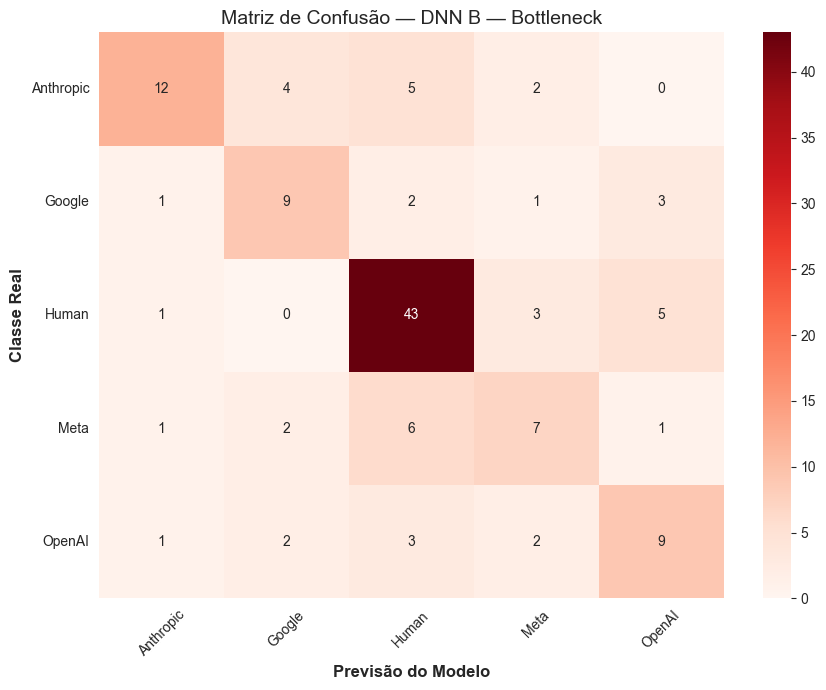


Classification Report — DNN B — Bottleneck:
              precision    recall  f1-score   support

   Anthropic       0.75      0.52      0.62        23
      Google       0.53      0.56      0.55        16
       Human       0.73      0.83      0.77        52
        Meta       0.47      0.41      0.44        17
      OpenAI       0.50      0.53      0.51        17

    accuracy                           0.64       125
   macro avg       0.59      0.57      0.58       125
weighted avg       0.64      0.64      0.63       125



In [50]:
# Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Previsão do Modelo', fontsize=12, fontweight='bold')
plt.ylabel('Classe Real', fontsize=12, fontweight='bold')
plt.title(f'Matriz de Confusão — {melhor_res["nome"]}', fontsize=14)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

print(f'\nClassification Report — {melhor_res["nome"]}:')
print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

### **9. Guardar o Modelo para Submissão**

In [51]:
import pickle

os.makedirs('../models', exist_ok=True)

model_path = '../models/pytorch.pth'
torch.save(melhor_model.state_dict(), model_path)
print(f"✅ Pesos do modelo guardados em '{model_path}'")

meta = {
    'model_class': melhor_model.__class__.__name__,
    'input_size': input_size,
    'num_classes': num_classes,
    'class_names': list(class_names),
    'transformers': transformers,
    'encoder': encoder,
    'melhor_resultado': {k: v for k, v in melhor_res.items() if k != 'history'},
}

# Se o melhor modelo é sequencial, guardar vocabulário e dimensões
if melhor_key in ['C', 'D', 'E']:
    meta['word2idx'] = word2idx
    meta['max_seq_len'] = MAX_SEQ_LEN
    meta['vocab_size'] = actual_vocab_size
    meta['hidden_dim'] = HIDDEN_DIM_GLOVE if melhor_key == 'E' else HIDDEN_DIM
    if melhor_key == 'C':
        meta['embed_dim'] = EMBED_DIM
    elif melhor_key == 'D':
        meta['embed_dim'] = EMBED_DIM
    elif melhor_key == 'E':
        meta['embed_dim'] = GLOVE_DIM
        meta['embedding_matrix'] = embedding_matrix

meta_path = '../models/pytorch.pkl'
with open(meta_path, 'wb') as f:
    pickle.dump(meta, f)
print(f"✅ Metadados guardados em '{meta_path}'")

print(f"\n📋 Para submissão, usar:")
print(f"   1. Carregar meta de '{meta_path}'")
print(f"   2. Reconstruir modelo {meta['model_class']}")
print(f"   3. model.load_state_dict(torch.load('{model_path}'))")
if melhor_key in ['A', 'B']:
    print(f"   4. Transformar textos com transform_new_texts(textos, meta['transformers'])")
else:
    print(f"   4. Tokenizar textos com texts_to_sequences(textos, meta['word2idx'], meta['max_seq_len'])")

✅ Pesos do modelo guardados em '../models/pytorch.pth'
✅ Metadados guardados em '../models/pytorch.pkl'

📋 Para submissão, usar:
   1. Carregar meta de '../models/pytorch.pkl'
   2. Reconstruir modelo DNNBottleneck
   3. model.load_state_dict(torch.load('../models/pytorch.pth'))
   4. Transformar textos com transform_new_texts(textos, meta['transformers'])
